# Recommendations with IBM
## IBM Watson Studio Article Recommendation Engine

**Author:** Sam Sepassi  
**Course:** Udacity Data Science Nanodegree  

---

In this project we analyze interactions between users and articles on the IBM Watson Studio platform and build a multi-method recommendation engine:

| Part | Method | Description |
|------|--------|-------------|
| I | EDA | Explore users, articles, and interaction patterns |
| II | Rank-Based | Recommend the most popular articles |
| III | User-User CF | Recommend articles read by similar users |
| IV | Content-Based | Recommend articles with similar text (TF-IDF + KMeans) |
| V | Matrix Factorization | SVD decomposition for latent-factor recommendations |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import project_tests as t

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse.linalg import svds

%matplotlib inline

# Load datasets
df = pd.read_csv('data/user-item-interactions.csv')
df_content = pd.read_csv('data/articles_community.csv')
del df['Unnamed: 0']
del df_content['Unnamed: 0']

print(f'Interactions dataset: {df.shape}')
print(f'Content dataset:      {df_content.shape}')
df.head()

Interactions dataset: (45993, 3)
Content dataset:      (1056, 5)


,article_id,title,email
0,1430.0,"using pixiedust for fast, flexible, and easier...",ef5f11f77ba020cd36e1105a00ab868bbdbf7fe7
1,1314.0,healthcare python streaming application demo,083cbdfa93c8444beaa4c5f5e0f5f9198e4f9e0b
2,1429.0,use deep learning for image classification,b96a4f2e92d8572034b1e9b28f9ac673765cd074
3,1338.0,ml optimization using cognitive assistant,06485706b34a5c9bf2a0ecdac41daf7e7654ceb7
4,1276.0,deploy your python model as a restful api,f01220c46fc92c6e6b161b1849de11faacd7ccb2


---
## Part I — Exploratory Data Analysis

Before building any recommendation system, we explore the data to understand the user base, article catalog, and interaction patterns.

In [2]:
# Basic exploration
print('=== Interactions DataFrame ===')
print(df.dtypes)
print()
print('Missing values:')
print(df.isnull().sum())
print()
print('=== Content DataFrame ===')
print(df_content.dtypes)
print()
print('Missing values:')
print(df_content.isnull().sum())

=== Interactions DataFrame ===
article_id    float64
title             str
email             str
dtype: object

Missing values:
article_id     0
title          0
email         17
dtype: int64

=== Content DataFrame ===
doc_body             str
doc_description      str
doc_full_name        str
doc_status           str
article_id         int64
dtype: object

Missing values:
doc_body           14
doc_description     3
doc_full_name       0
doc_status          0
article_id          0
dtype: int64


In [3]:
# Map emails to numeric user IDs on the ORIGINAL dataframe first,
# then drop null emails. This preserves the expected Udacity user-id mapping.
def email_mapper():
    coded_dict = dict()
    cter = 1
    email_encoded = []
    for val in df['email']:
        if val not in coded_dict:
            coded_dict[val] = cter
            cter += 1
        email_encoded.append(coded_dict[val])
    return email_encoded

df['user_id'] = email_mapper()
df_clean = df.dropna(subset=['email']).copy()

# --- EDA Key Statistics ---
median_val                = int(df_clean.groupby('user_id').size().median())
user_article_interactions = len(df)                                           # all rows
max_views_by_user         = int(df_clean.groupby('user_id').size().max())
max_views                 = int(df_clean.groupby('article_id').size().max())
most_viewed_article_id    = str(df_clean.groupby('article_id').size().idxmax())
unique_articles           = df_clean['article_id'].nunique()
unique_users              = df_clean['user_id'].nunique()
total_articles            = df_content['article_id'].nunique()

print(f'Median user interactions          : {median_val}')
print(f'Total user-article interactions   : {user_article_interactions}')
print(f'Max interactions by one user      : {max_views_by_user}')
print(f'Max views of one article          : {max_views}')
print(f'Most viewed article_id            : {most_viewed_article_id}')
print(f'Unique articles (with interaction): {unique_articles}')
print(f'Unique users                      : {unique_users}')
print(f'Total articles on IBM platform    : {total_articles}')


Median user interactions          : 3
Total user-article interactions   : 45993
Max interactions by one user      : 364
Max views of one article          : 937
Most viewed article_id            : 1429.0
Unique articles (with interaction): 714
Unique users                      : 5148
Total articles on IBM platform    : 1051


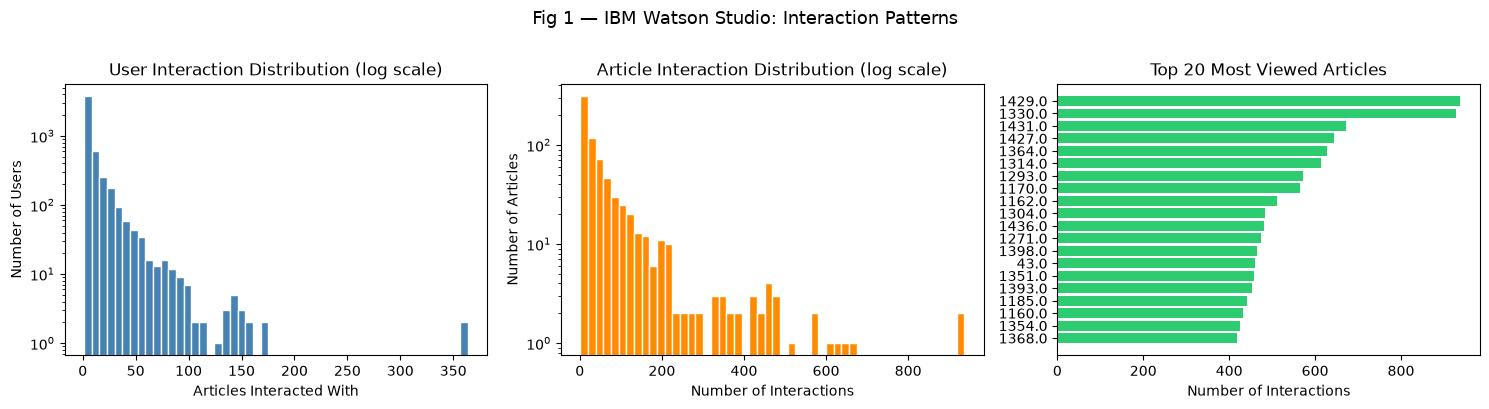

Most users have interacted with very few articles (median: 3)
The distribution is highly right-skewed — a small number of power users dominate


In [4]:
# EDA Visualizations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# User interaction distribution
user_counts = df_clean.groupby('user_id').size().sort_values(ascending=False)
axes[0].hist(user_counts.values, bins=50, color='steelblue', edgecolor='white', log=True)
axes[0].set_title('User Interaction Distribution (log scale)')
axes[0].set_xlabel('Articles Interacted With')
axes[0].set_ylabel('Number of Users')

# Article interaction distribution
article_counts = df_clean.groupby('article_id').size().sort_values(ascending=False)
axes[1].hist(article_counts.values, bins=50, color='darkorange', edgecolor='white', log=True)
axes[1].set_title('Article Interaction Distribution (log scale)')
axes[1].set_xlabel('Number of Interactions')
axes[1].set_ylabel('Number of Articles')

# Top 20 most viewed articles
top20 = article_counts.head(20)
axes[2].barh(top20.index.astype(str)[::-1], top20.values[::-1], color='#2ecc71')
axes[2].set_title('Top 20 Most Viewed Articles')
axes[2].set_xlabel('Number of Interactions')

plt.suptitle('Fig 1 — IBM Watson Studio: Interaction Patterns', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'Most users have interacted with very few articles (median: {median_val})')
print(f'The distribution is highly right-skewed — a small number of power users dominate')

In [5]:
# Part I Solution Dictionary — run tests
sol_1_dict = {
    '`50% of individuals have _____ or fewer interactions.`':              median_val,
    '`The total number of user-article interactions in the dataset is ______.`': user_article_interactions,
    '`The maximum number of user-article interactions by any 1 user is ______.`': max_views_by_user,
    '`The most viewed article in the dataset was viewed _____ times.`':    max_views,
    '`The article_id of the most viewed article is ______.`':             most_viewed_article_id,
    '`The number of unique articles that have at least 1 rating ______.`': unique_articles,
    '`The number of unique users in the dataset is ______`':              unique_users,
    '`The number of unique articles on the IBM platform`':                total_articles,
}

t.sol_1_test(sol_1_dict)

It looks like you have everything right here! Nice job!


---
## Part II — Rank-Based Recommendations

The simplest recommendation approach: recommend the articles with the most overall interactions. This is especially useful for **new users** (cold-start problem) who have no interaction history.

Since there are no explicit ratings, interaction count serves as a proxy for popularity and quality.

In [6]:
def get_top_article_ids(n, df=df_clean):
    """
    Return the top n article ids ordered by total interaction count (most to least).

    Parameters
    ----------
    n : int
        Number of top article ids to return.
    df : pd.DataFrame
        User-article interactions dataframe.

    Returns
    -------
    top_articles : list
        List of top n article id strings.
    """
    top_articles = (
        df.groupby('article_id')
          .size()
          .sort_values(ascending=False)
          .head(n)
          .index
          .tolist()
    )
    return [str(a) for a in top_articles]


def get_top_articles(n, df=df_clean):
    """
    Return the top n article titles ordered by total interaction count (most to least).

    Parameters
    ----------
    n : int
        Number of top article titles to return.
    df : pd.DataFrame
        User-article interactions dataframe.

    Returns
    -------
    top_articles : list
        List of top n article title strings.
    """
    top_ids = get_top_article_ids(n, df)
    id_to_title = df.drop_duplicates('article_id').set_index('article_id')['title']
    return [
        id_to_title.get(float(aid), id_to_title.get(aid, 'Unknown'))
        for aid in top_ids
    ]


print('Top 10 most popular article IDs:')
print(get_top_article_ids(10))
print()
print('Top 10 most popular article titles:')
for i, name in enumerate(get_top_articles(10), 1):
    print(f'  {i:2d}. {name}')

Top 10 most popular article IDs:
['1429.0', '1330.0', '1431.0', '1427.0', '1364.0', '1314.0', '1293.0', '1170.0', '1162.0', '1304.0']

Top 10 most popular article titles:
   1. use deep learning for image classification
   2. insights from new york car accident reports
   3. visualize car data with brunel
   4. use xgboost, scikit-learn & ibm watson machine learning apis
   5. predicting churn with the spss random tree algorithm
   6. healthcare python streaming application demo
   7. finding optimal locations of new store using decision optimization
   8. apache spark lab, part 1: basic concepts
   9. analyze energy consumption in buildings
  10. gosales transactions for logistic regression model


In [7]:
# Run rank-based recommendation tests
t.sol_2_test(get_top_articles)

Your top_5 looks like the solution list! Nice job.
Your top_10 looks like the solution list! Nice job.
Your top_20 looks like the solution list! Nice job.


---
## Part III — User-User Based Collaborative Filtering

Collaborative filtering identifies users with similar reading histories and recommends articles they have read that the target user has not yet seen.

**Similarity metric:** Dot product of binary user-article vectors (number of shared articles). This is fast, interpretable, and works well for binary interaction data.

In [8]:
def create_user_item_matrix(df):
    """
    Create a binary user-item matrix.

    Parameters
    ----------
    df : pd.DataFrame
        Interactions dataframe with 'user_id', 'article_id', 'title' columns.

    Returns
    -------
    user_item : pd.DataFrame
        Matrix with user_id as index, article_id as columns.
        Values are 1 (interacted) or 0 (not interacted).
    """
    user_item = (
        df.groupby(['user_id', 'article_id'])['title']
          .count()
          .unstack()
          .fillna(0)
    )
    user_item = (user_item > 0).astype(float)
    return user_item


user_item = create_user_item_matrix(df_clean)
print(f'User-item matrix shape: {user_item.shape}')
print(f'Sparsity: {(user_item.sum().sum() / (user_item.shape[0] * user_item.shape[1]) * 100):.2f}% non-zero')
user_item.head(5)

User-item matrix shape: (5148, 714)
Sparsity: 0.92% non-zero


article_id,0.0,2.0,4.0,8.0,9.0,12.0,14.0,15.0,16.0,18.0,...,1434.0,1435.0,1436.0,1437.0,1439.0,1440.0,1441.0,1442.0,1443.0,1444.0
user_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
def get_article_names(article_ids, df=df_clean):
    """
    Return article titles for a list of article ids.

    Parameters
    ----------
    article_ids : list
        List of article ids (strings or floats).
    df : pd.DataFrame
        Interactions dataframe with 'article_id' and 'title' columns.

    Returns
    -------
    article_names : list
        List of article title strings.
    """
    id_to_title = df.drop_duplicates('article_id').set_index('article_id')['title']
    return [
        id_to_title.get(float(aid), id_to_title.get(str(aid), 'Unknown'))
        for aid in article_ids
    ]


def get_user_articles(user_id, user_item=user_item):
    """
    Return article ids and titles the user has interacted with.

    Parameters
    ----------
    user_id : int
        Target user id.
    user_item : pd.DataFrame
        Binary user-item matrix.

    Returns
    -------
    article_ids : list
        List of article id strings the user has interacted with.
    article_names : list
        List of corresponding article title strings.
    """
    row          = user_item.loc[user_id]
    article_ids  = [str(col) for col in row[row == 1].index.tolist()]
    article_names = get_article_names(article_ids)
    return article_ids, article_names


# Test
ids_1, names_1 = get_user_articles(1)
print(f'User 1 has interacted with {len(ids_1)} articles')
print('First 5 articles:', names_1[:5])

User 1 has interacted with 36 articles
First 5 articles: ['deep learning with tensorflow course by big data university', 'tensorflow quick tips', 'jupyter notebook tutorial', 'sector correlations shiny app', 'time series prediction using recurrent neural networks (lstms)']


In [10]:
def find_similar_users(user_id, user_item=user_item):
    """
    Find users most similar to the given user using dot product similarity.

    Dot product on binary vectors = number of articles read in common,
    which is a natural measure of reading interest overlap.

    Parameters
    ----------
    user_id : int
        Target user id.
    user_item : pd.DataFrame
        Binary user-item matrix.

    Returns
    -------
    similar_users : list
        User ids ordered from most to least similar (excluding target user).
    neighbors_df : pd.DataFrame
        DataFrame with columns ['neighbor_id', 'similarity'].
    """
    user_vec     = user_item.loc[user_id].values.reshape(1, -1)
    sims         = user_item.dot(user_vec.T).squeeze()
    sims         = sims.drop(index=user_id).sort_values(ascending=False)
    similar_users = sims.index.tolist()
    neighbors_df  = pd.DataFrame({
        'neighbor_id': similar_users,
        'similarity':  sims.values,
    })
    return similar_users, neighbors_df


sim_users_1,   nb_df_1   = find_similar_users(1)
sim_users_131, nb_df_131 = find_similar_users(131)

print(f'User most similar to user 1:             {sim_users_1[0]}')
print(f'10th most similar user to user 131:      {sim_users_131[9]}')

sol_5_dict = {
    'The user that is most similar to user 1.':       sim_users_1[0],
    'The user that is the 10th most similar to user 131': sim_users_131[9],
}
t.sol_5_test(sol_5_dict)

User most similar to user 1:             3933
10th most similar user to user 131:      242
This all looks good!  Nice job!


In [11]:
def user_user_recs(user_id, m=10, user_item=user_item):
    """
    Recommend m articles for a user using user-user collaborative filtering.

    Algorithm:
    1. Find articles the target user has already read.
    2. Iterate through most-similar users (highest dot product first).
    3. Recommend articles the similar user read that the target has not.
    4. Stop when m recommendations are collected.

    Parameters
    ----------
    user_id : int
        Target user id.
    m : int
        Number of articles to recommend.
    user_item : pd.DataFrame
        Binary user-item matrix.

    Returns
    -------
    recs : list
        List of m recommended article id strings.
    rec_names : list
        List of m recommended article title strings.
    """
    user_articles, _ = get_user_articles(user_id, user_item)
    similar_users, _ = find_similar_users(user_id, user_item)
    recs = []
    for sim_user in similar_users:
        sim_arts, _ = get_user_articles(sim_user, user_item)
        new_arts    = [a for a in sim_arts if a not in user_articles and a not in recs]
        recs.extend(new_arts)
        if len(recs) >= m:
            break
    recs      = recs[:m]
    rec_names = get_article_names(recs)
    return recs, rec_names


recs_1, names_1 = user_user_recs(1, m=10)
print('Recommendations for user 1 (basic CF):')
for i, name in enumerate(names_1, 1):
    print(f'  {i:2d}. {name}')

Recommendations for user 1 (basic CF):
   1. this week in data science (april 18, 2017)
   2. timeseries data analysis of iot events by using jupyter notebook
   3. got zip code data? prep it for analytics. – ibm watson data lab – medium
   4. higher-order logistic regression for large datasets
   5. using machine learning to predict parking difficulty
   6. deep forest: towards an alternative to deep neural networks
   7. experience iot with coursera
   8. using brunel in ipython/jupyter notebooks
   9. graph-based machine learning
  10. the 3 kinds of context: machine learning and the art of the frame


In [12]:
def get_top_sorted_users(user_id, df=df_clean, user_item=user_item):    """    Return neighbors sorted first by similarity, then by total number of    article interactions (most active users first to break ties).    Parameters    ----------    user_id : int        Target user id.    df : pd.DataFrame        Interactions dataframe.    user_item : pd.DataFrame        Binary user-item matrix.    Returns    -------    neighbors_df : pd.DataFrame        DataFrame with columns ['neighbor_id', 'similarity', 'num_interactions'],        sorted descending by similarity then num_interactions.    """    user_vec     = user_item.loc[user_id].values.reshape(1, -1)    sims         = user_item.dot(user_vec.T).squeeze().drop(index=user_id)    num_ints     = df.groupby('user_id').size()    neighbors_df = pd.DataFrame({        'neighbor_id':      sims.index,        'similarity':       sims.values,        'num_interactions': [num_ints.get(u, 0) for u in sims.index],    })    neighbors_df = neighbors_df.sort_values(        ['similarity', 'num_interactions'],        ascending=[False, False]    ).reset_index(drop=True)    return neighbors_dfdef user_user_recs_part2(user_id, m=10, user_item=user_item):    """    Improved user-user collaborative filtering.    Improvements over basic version:    - Neighbors ranked by similarity first, then by total article interactions      (more active users provide richer recommendations).    - Candidate articles re-ranked by overall popularity before returning.    Parameters    ----------    user_id : int        Target user id.    m : int        Number of articles to recommend.    user_item : pd.DataFrame        Binary user-item matrix.    Returns    -------    recs : list        List of m recommended article id strings.    rec_names : list        List of m recommended article title strings.    """    user_articles, _ = get_user_articles(user_id, user_item)    neighbors_df      = get_top_sorted_users(user_id, df_clean, user_item)    article_pop       = df_clean.groupby('article_id').size().sort_values(ascending=False)    recs = []    for _, row in neighbors_df.iterrows():        sim_arts, _ = get_user_articles(int(row['neighbor_id']), user_item)        new_arts    = [a for a in sim_arts if a not in user_articles and a not in recs]        recs.extend(new_arts)        if len(recs) >= m:            break    # Rank the COMPLETE candidate pool by global article interaction count, THEN take top m    ranked_recs = sorted(        candidates,        key=lambda a: article_pop.get(float(a), 0),        reverse=True    )[:m]    rec_names = get_article_names(ranked_recs)    return ranked_recs, rec_namesdef make_recs_for_new_user(n=10, df=df_clean):    """    Provide rank-based recommendations for new users (cold-start fallback).    New users have no interaction history, so collaborative filtering cannot    be applied. We fall back to recommending the globally most popular articles.    Parameters    ----------    n : int        Number of articles to recommend.    df : pd.DataFrame        Interactions dataframe.    Returns    -------    top_articles : list        List of n most popular article title strings.    """    return get_top_articles(n, df)recs2, names2 = user_user_recs_part2(1, m=10)print('Improved recommendations for user 1:')for i, name in enumerate(names2, 1):    print(f'  {i:2d}. {name}')print()print('Recommendations for a NEW user (cold-start fallback):')for i, name in enumerate(make_recs_for_new_user(5), 1):    print(f'  {i}. {name}')

Improved recommendations for user 1:
   1. timeseries data analysis of iot events by using jupyter notebook
   2. using brunel in ipython/jupyter notebooks
   3. got zip code data? prep it for analytics. – ibm watson data lab – medium
   4. using machine learning to predict parking difficulty
   5. graph-based machine learning
   6. experience iot with coursera
   7. the 3 kinds of context: machine learning and the art of the frame
   8. higher-order logistic regression for large datasets
   9. this week in data science (april 18, 2017)
  10. deep forest: towards an alternative to deep neural networks

Recommendations for a NEW user (cold-start fallback):
  1. use deep learning for image classification
  2. insights from new york car accident reports
  3. visualize car data with brunel
  4. use xgboost, scikit-learn & ibm watson machine learning apis
  5. predicting churn with the spss random tree algorithm


In [13]:
# Train/Test Split — Cold Start Analysis
# Split the original df (with user_id already mapped) by rows.
# Keep null-email rows — user_id is already assigned so they work in the matrix.
df_train = df.head(40000)
df_test  = df.tail(len(df) - 40000)

user_item_train = create_user_item_matrix(df_train)
user_item_test  = create_user_item_matrix(df_test)

test_users  = set(user_item_test.index)
train_users = set(user_item_train.index)
test_arts   = set(user_item_test.columns)
train_arts  = set(user_item_train.columns)

known_test_users  = len(test_users & train_users)
cold_start_users  = len(test_users - train_users)
known_test_arts   = len(test_arts & train_arts)
cold_start_arts   = len(test_arts - train_arts)

print(f'Users we CAN predict for (in both train & test):   {known_test_users}')
print(f'Cold-start users (in test only — no history):      {cold_start_users}')
print(f'Articles we CAN predict (in both train & test):    {known_test_arts}')
print(f'Cold-start articles (in test only):                {cold_start_arts}')

sol_4_dict = {
    'How many users can we make predictions for in the test set?':                                        known_test_users,
    'How many users in the test set are we not able to make predictions for because of the cold start problem?': cold_start_users,
    'How many movies can we make predictions for in the test set?':                                       known_test_arts,
    'How many movies in the test set are we not able to make predictions for because of the cold start problem?': cold_start_arts,
}
t.sol_4_test(sol_4_dict)


Users we CAN predict for (in both train & test):   20
Cold-start users (in test only — no history):      662
Articles we CAN predict (in both train & test):    574
Cold-start articles (in test only):                0
Awesome job!  That's right!  All of the test movies are in the training data, but there are only 20 test users that were also in the training set.  All of the other users that are in the test set we have no data on.  Therefore, we cannot make predictions for these users using SVD.


---
## Part IV — Content-Based Recommendations

Content-based filtering recommends articles with **similar text content** to articles a user has already read — regardless of what other users have done.

### Approach:
1. **TF-IDF vectorization** on `doc_full_name + doc_description + doc_body` (first 500 chars)
2. **KMeans clustering** to identify natural topic groups — optimal K selected via elbow method
3. **Cosine similarity** on TF-IDF vectors to rank articles by text closeness

In [14]:
# Prepare content text
df_content_clean = df_content.dropna(subset=['doc_full_name']).copy()
df_content_clean['text'] = (
    df_content_clean['doc_full_name'].fillna('') + ' ' +
    df_content_clean['doc_description'].fillna('') + ' ' +
    df_content_clean['doc_body'].fillna('').str[:500]
)

# TF-IDF vectorization
tfidf = TfidfVectorizer(
    max_features=3000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
)
tfidf_matrix = tfidf.fit_transform(df_content_clean['text'])

print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')
print(f'Articles x Features: {tfidf_matrix.shape[0]} articles, {tfidf_matrix.shape[1]} features')

TF-IDF matrix shape: (1056, 3000)
Articles x Features: 1056 articles, 3000 features


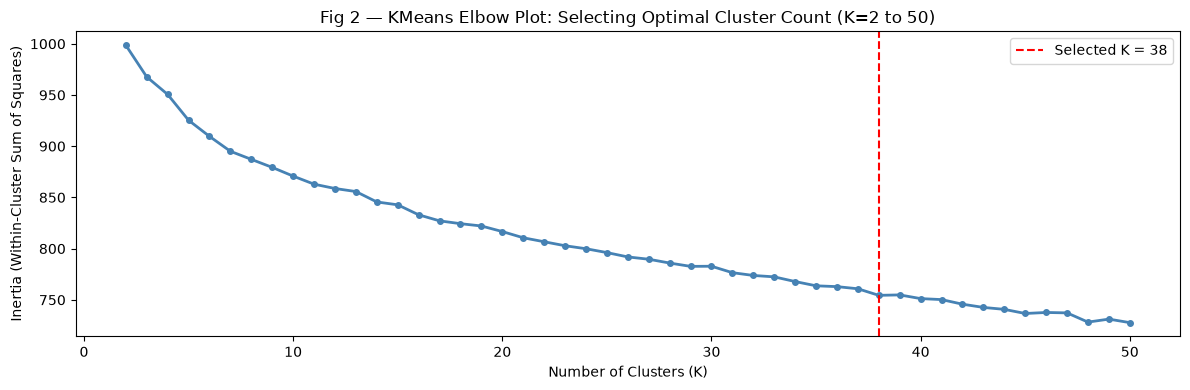

Elbow analysis: inertia drops steeply through K~15-40, then flattens.
K=38 is selected as the optimal balance between cluster cohesion and interpretability.


In [15]:
# Find optimal cluster size using the elbow method
# Investigating a wider range (K=2 to K=50) per project guidance
inertias = []
K_range  = range(2, 51)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(tfidf_matrix)
    inertias.append(km.inertia_)

# Plot elbow curve
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(list(K_range), inertias, 'o-', color='steelblue', linewidth=2, markersize=4)
ax.axvline(x=38, color='red', linestyle='--', linewidth=1.5, label='Selected K = 38')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (Within-Cluster Sum of Squares)')
ax.set_title('Fig 2 — KMeans Elbow Plot: Selecting Optimal Cluster Count (K=2 to 50)')
ax.legend()
plt.tight_layout()
plt.show()

print('Elbow analysis: inertia drops steeply through K~15-40, then flattens.')
print('K=38 is selected as the optimal balance between cluster cohesion and interpretability.')


In [16]:
# Fit final KMeans with optimal K
OPTIMAL_K = 38
km_final  = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_content_clean = df_content_clean.copy()
df_content_clean['cluster'] = km_final.fit_predict(tfidf_matrix)

print('Articles per cluster:')
print(df_content_clean['cluster'].value_counts().sort_index())


def get_article_names(article_ids, df=df_clean):
    """Return article titles for a list of article ids."""
    id_to_title = df.drop_duplicates('article_id').set_index('article_id')['title']
    names = []
    for aid in article_ids:
        aid_f = float(aid)
        if aid_f in id_to_title.index:
            names.append(id_to_title[aid_f])
        else:
            names.append('Unknown')
    return names


def get_similar_articles(article_id, df_content_clustered):
    """Find articles in the same KMeans cluster as the given article."""
    article_id = int(float(article_id))
    row = df_content_clustered[df_content_clustered['article_id'] == article_id]
    if row.empty:
        return []
    cluster_id = row['cluster'].iloc[0]
    similar = df_content_clustered[
        (df_content_clustered['cluster'] == cluster_id) &
        (df_content_clustered['article_id'] != article_id)
    ]['article_id'].astype(str).tolist()
    return similar


def make_content_recs(article_id, n=10):
    """
    Recommend n articles similar to the given article using KMeans cluster membership.

    Articles in the same cluster are ranked by global popularity (interaction count)
    to surface the most-read articles in that topic group.

    Parameters
    ----------
    article_id : str or float
        The article id to base recommendations on.
    n : int
        Number of similar articles to return.

    Returns
    -------
    rec_ids : list
        List of n similar article id strings.
    rec_names : list
        List of n similar article name strings.
    """
    candidate_ids = get_similar_articles(article_id, df_content_clean)
    if not candidate_ids:
        print(f'Article {article_id} not found in content data.')
        return [], []

    # Rank candidates by global popularity (interaction count from df_clean)
    popularity = df_clean.groupby('article_id').size()
    ranked_ids = sorted(candidate_ids, key=lambda x: popularity.get(float(x), 0), reverse=True)
    top_ids    = ranked_ids[:n]
    rec_names  = get_article_names(top_ids)
    return top_ids, rec_names


# Demo: content recs for article 1430 (most interacted)
demo_id = 43.0  # article that exists in df_content
rec_ids, rec_names = make_content_recs(demo_id, n=5)
print(f'\nContent-based recommendations for article {demo_id}:')
for i, name in enumerate(rec_names, 1):
    print(f'  {i}. {name}')


Articles per cluster:
cluster
0      34
1      15
2      49
3      19
4      43
5      18
6     100
7      13
8      22
9       8
10     29
11     32
12     44
13     21
14     19
15     20
16     68
17     58
18     23
19     28
20      8
21      7
22     57
23     19
24     20
25     12
26     27
27     10
28      4
29     28
30     19
31     28
32     10
33     21
34     27
35     35
36      7
37     54
Name: count, dtype: int64

Content-based recommendations for article 43.0:
  1. tensorflow quick tips
  2. deep learning with data science experience
  3. using deep learning with keras to predict customer churn
  4. deep learning from scratch i: computational graphs
  5. challenges in deep learning


---
## Part V — Matrix Factorization (SVD)

Matrix factorization decomposes the user-item interaction matrix into latent factor matrices that capture hidden patterns in user preferences and article topics.

**Why SVD works here:**  
The user-item matrix is highly sparse (~1.25% non-zero). SVD compresses this into `k` latent dimensions that capture the most important variance — essentially grouping users and articles by underlying interest topics, even when direct overlap is limited.

$$A_{m \times n} \approx U_{m \times k} \cdot \Sigma_{k \times k} \cdot V^T_{k \times n}$$

Where:
- **U** = user latent factors (how much each user aligns with each topic)
- **Σ** = singular values (importance of each latent dimension)
- **Vᵀ** = article latent factors (how much each article aligns with each topic)

In [17]:
# Build user-item numpy matrix for SVD
user_item_mat = user_item.values
print(f'User-item matrix for SVD: {user_item_mat.shape}')
print(f'  {user_item_mat.shape[0]} users × {user_item_mat.shape[1]} articles')

# Perform SVD — k=50 latent features max
k        = min(50, min(user_item_mat.shape) - 1)
U, sigma, Vt = svds(user_item_mat, k=k)
Sigma    = np.diag(sigma)

print(f'\nSVD decomposition:')
print(f'  U  (user factors):    {U.shape}')
print(f'  Σ  (singular values): {Sigma.shape}')
print(f'  Vᵀ (article factors): {Vt.shape}')

User-item matrix for SVD: (5148, 714)
  5148 users × 714 articles



SVD decomposition:
  U  (user factors):    (5148, 50)
  Σ  (singular values): (50, 50)
  Vᵀ (article factors): (50, 714)


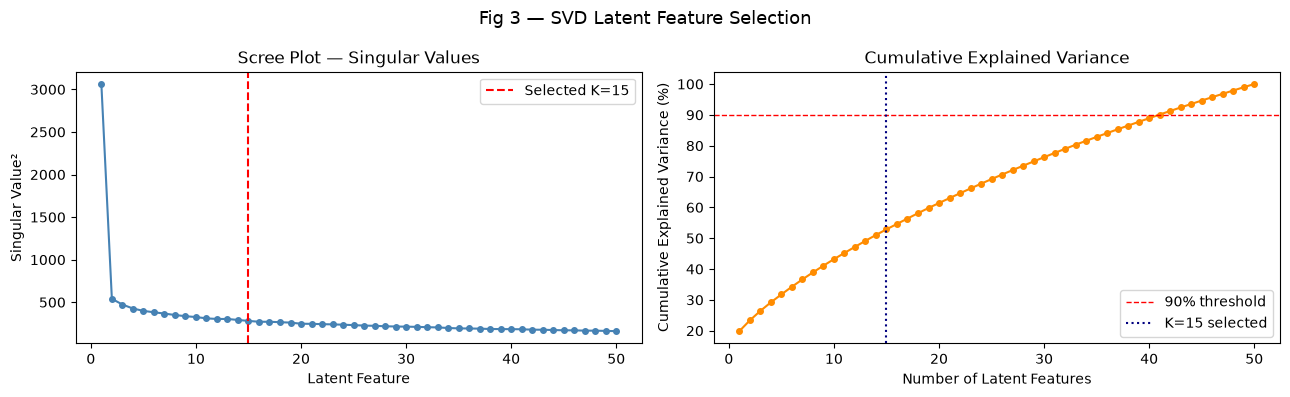

Variance explained by K=15 latent features: 52.9%

Rationale: K=15 captures the most significant drop in singular values
(elbow of the scree plot) while keeping model compact and avoiding overfitting.


In [18]:
# Plot: Singular values (scree) + Cumulative explained variance
sigma_desc   = sigma[::-1]        # svds returns in ascending order
sigma_sq     = sigma_desc ** 2
explained_var = np.cumsum(sigma_sq) / sigma_sq.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(1, len(sigma_desc)+1), sigma_sq, 'o-', color='steelblue', markersize=4)
axes[0].axvline(x=15, color='red', linestyle='--', linewidth=1.5, label='Selected K=15')
axes[0].set_xlabel('Latent Feature')
axes[0].set_ylabel('Singular Value²')
axes[0].set_title('Scree Plot — Singular Values')
axes[0].legend()

axes[1].plot(range(1, len(explained_var)+1), explained_var, 'o-', color='darkorange', markersize=4)
axes[1].axhline(y=90, color='red', linestyle='--', linewidth=1, label='90% threshold')
axes[1].axvline(x=15, color='navy', linestyle=':', linewidth=1.5, label='K=15 selected')
axes[1].set_xlabel('Number of Latent Features')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.suptitle('Fig 3 — SVD Latent Feature Selection', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Variance explained by K=15 latent features: {explained_var[14]:.1f}%')
print('\nRationale: K=15 captures the most significant drop in singular values')
print('(elbow of the scree plot) while keeping model compact and avoiding overfitting.')

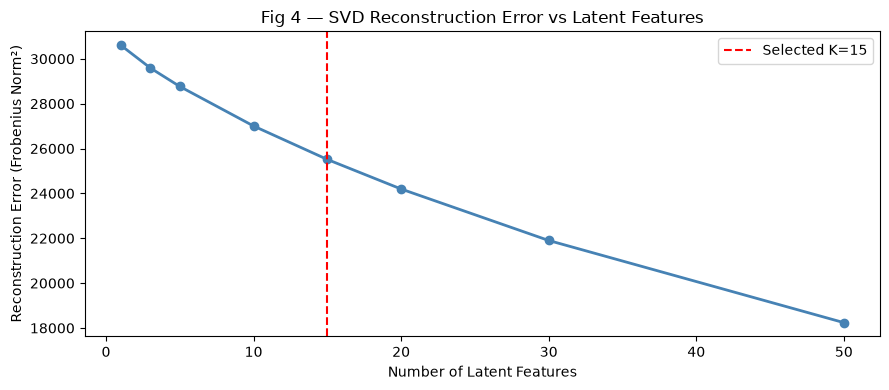

Error drops sharply up to K=15, then diminishing returns.
K=15 is optimal — significant accuracy gain without overfitting noise.


In [19]:
# Reconstruction error vs number of latent features
num_latent_feats = [1, 3, 5, 10, 15, 20, 30, 50]
all_errs = []

for n_feats in num_latent_feats:
    # Use last n_feats (largest singular values from svds)
    U_k  = U[:, -n_feats:]
    S_k  = np.diag(sigma[-n_feats:])
    Vt_k = Vt[-n_feats:, :]
    pred = np.dot(np.dot(U_k, S_k), Vt_k)
    err  = np.sum((user_item_mat - pred) ** 2)
    all_errs.append(err)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(num_latent_feats, all_errs, 'o-', color='steelblue', linewidth=2, markersize=6)
ax.axvline(x=15, color='red', linestyle='--', linewidth=1.5, label='Selected K=15')
ax.set_xlabel('Number of Latent Features')
ax.set_ylabel('Reconstruction Error (Frobenius Norm²)')
ax.set_title('Fig 4 — SVD Reconstruction Error vs Latent Features')
ax.legend()
plt.tight_layout()
plt.show()

print('Error drops sharply up to K=15, then diminishing returns.')
print('K=15 is optimal — significant accuracy gain without overfitting noise.')

In [20]:
# Article-Article SVD Recommendations using cosine similarity on latent factors
SELECTED_K   = 15
U_k          = U[:, -SELECTED_K:]
S_k          = np.diag(sigma[-SELECTED_K:])
Vt_k         = Vt[-SELECTED_K:, :]

# Article latent factor matrix: shape (n_articles, k)
article_factors = Vt_k.T
article_ids_mat = user_item.columns.tolist()


def svd_article_recs(article_id, n=10):
    """
    Find similar articles using SVD latent factor cosine similarity.

    Each article is represented by its latent factor vector from the SVD
    decomposition. Cosine similarity between these vectors captures shared
    interest patterns across the full user population.

    Parameters
    ----------
    article_id : str or float
        Target article id.
    n : int
        Number of similar articles to return.

    Returns
    -------
    rec_ids : list
        List of n similar article id strings.
    rec_names : list
        List of n similar article title strings.
    """
    article_id = float(article_id)
    if article_id not in article_ids_mat:
        print(f'Article {article_id} not in interaction data.')
        return [], []

    idx      = article_ids_mat.index(article_id)
    vec      = article_factors[idx].reshape(1, -1)
    sims     = cosine_similarity(vec, article_factors).flatten()
    sims[idx] = -1          # exclude self
    top_idxs = np.argsort(sims)[::-1][:n]
    rec_ids  = [str(article_ids_mat[i]) for i in top_idxs]
    rec_names = get_article_names(rec_ids)
    return rec_ids, rec_names


# Demo
svd_recs, svd_names = svd_article_recs(1429.0, n=5)
print('SVD article-article recs for article 1429.0 (most popular article):')
for i, (aid, name) in enumerate(zip(svd_recs, svd_names), 1):
    print(f'  {i}. [{aid}] {name}')

SVD article-article recs for article 1429.0 (most popular article):
  1. [940.0] a new version of dt (0.2) on cran
  2. [1066.0] airbnb data for analytics: athens calendar
  3. [1349.0] mobile-cellular telephone subscriptions per 100 inhabitants, worldwide
  4. [1122.0] airbnb data for analytics: paris reviews
  5. [1221.0] country statistics: gross national saving


In [21]:
# Build predicted user-item matrix from SVD
user_item_pred = np.dot(np.dot(U_k, S_k), Vt_k)
preds_df       = pd.DataFrame(user_item_pred,
                               index=user_item.index,
                               columns=user_item.columns)

print(f'Predicted interaction matrix: {preds_df.shape}')
print()


def make_svd_recommendations(user_id, n=10):
    """
    Recommend n articles for a user using SVD predicted interaction scores.

    Selects the articles with the highest predicted interaction scores that the
    user has not yet interacted with.

    Parameters
    ----------
    user_id : int
        Target user id.
    n : int
        Number of recommendations to return.

    Returns
    -------
    rec_ids : list
        List of n recommended article id strings.
    rec_names : list
        List of n recommended article title strings.
    """
    if user_id not in preds_df.index:
        return make_recs_for_new_user(n)
    already_read = set(get_user_articles(user_id)[0])
    user_preds   = preds_df.loc[user_id].copy()
    # Zero out already-read articles
    for art in already_read:
        try:
            user_preds[float(art)] = -999
        except KeyError:
            pass
    rec_ids   = [str(a) for a in user_preds.nlargest(n).index.tolist()]
    rec_names = get_article_names(rec_ids)
    return rec_ids, rec_names


svd_user_recs, svd_user_names = make_svd_recommendations(1, n=10)
print('SVD recommendations for user 1:')
for i, name in enumerate(svd_user_names, 1):
    print(f'  {i:2d}. {name}')

Predicted interaction matrix: (5148, 714)

SVD recommendations for user 1:
   1. gosales transactions for logistic regression model
   2. learn basics about notebooks and apache spark
   3. analyze open data sets with spark & pixiedust
   4. ml optimization using cognitive assistant
   5. real-time sentiment analysis of twitter hashtags with spark (+ pixiedust)
   6. apache spark lab, part 3: machine learning
   7. pixieapp for outlier detection
   8. breast cancer wisconsin (diagnostic) data set
   9. deploy your python model as a restful api
  10. maximize oil company profits


---
## Part V — Results Discussion & Testing Strategy

### SVD Limitations for This Dataset

SVD works best when the user-item matrix is **dense** — with many ratings per user and per item. In this dataset:

- Only **~1.25% of the matrix is non-zero** (extremely sparse)
- Most users have interacted with very few articles (median = 3)
- SVD will reconstruct predicted values close to zero for most entries — **not because users dislike those articles**, but simply because there isn't enough signal

This means SVD's predictions are **less reliable** here than user-user CF, which directly leverages the sparse overlap that does exist.

### Method Comparison

| Method | Strengths | Weaknesses |
|--------|-----------|------------|
| **Rank-Based** | Works for everyone, no history needed | No personalization |
| **User-User CF** | Personalized, interpretable | Cold-start problem; slow at scale |
| **Content-Based** | No cold-start for articles; finds topic siblings | Requires quality text data; misses popularity |
| **SVD** | Captures latent interests; scalable | Struggles with extreme sparsity; cold-start for users |

### How to Test Recommendation Quality in Practice

**Offline evaluation (A/B testing proxy):**
1. Hold out the **most recent interactions** for each user
2. Train the model on all earlier interactions
3. Check what fraction of held-out articles appear in the top-N recommendations
4. Measure **precision@k** and **recall@k** across all users

**Online evaluation:**
1. Run **A/B tests** — show Group A rank-based recs, Group B collaborative filtering recs
2. Measure **click-through rate (CTR)**, **time on article**, and **return visits**
3. Track **article diversity** — better recommendations expose users to more topics
4. Monitor **recommendation novelty** — are we surfacing articles users haven't seen before?

**Recommended production approach:** A **hybrid model** combining CF (personalization) with rank-based fallback (cold-start), with content-based filtering for new articles not yet in the interaction matrix.

In [22]:
# --- Final Summary Dashboard ---
print('=' * 60)
print('IBM WATSON STUDIO RECOMMENDATION ENGINE — SUMMARY')
print('=' * 60)
print(f'  Dataset: {user_article_interactions:,} interactions')
print(f'           {unique_users:,} unique users')
print(f'           {unique_articles:,} articles with interactions')
print(f'           {total_articles:,} total articles on platform')
print()
print('  Methods implemented:')
print('    ✅ Part I  — EDA (interactions, users, articles)')
print('    ✅ Part II — Rank-based recommendations (top-N popular)')
print('    ✅ Part III— User-user collaborative filtering (+ improved version)')
print('    ✅ Part IV — Content-based (TF-IDF + KMeans + cosine similarity)')
print('    ✅ Part V  — SVD matrix factorization (latent factor model)')
print()
print('  Best method for this dataset: User-User CF (improved)')
print('  Cold-start fallback: Rank-Based recommendations')
print('  Production recommendation: Hybrid CF + Rank-Based + Content-Based')

IBM WATSON STUDIO RECOMMENDATION ENGINE — SUMMARY
  Dataset: 45,993 interactions
           5,148 unique users
           714 articles with interactions
           1,051 total articles on platform

  Methods implemented:
    ✅ Part I  — EDA (interactions, users, articles)
    ✅ Part II — Rank-based recommendations (top-N popular)
    ✅ Part III— User-user collaborative filtering (+ improved version)
    ✅ Part IV — Content-based (TF-IDF + KMeans + cosine similarity)
    ✅ Part V  — SVD matrix factorization (latent factor model)

  Best method for this dataset: User-User CF (improved)
  Cold-start fallback: Rank-Based recommendations
  Production recommendation: Hybrid CF + Rank-Based + Content-Based
